In [206]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import missingno as msno

In [207]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [208]:
df_productivity = pd.read_csv(PATH)

In [209]:
print("Dataset shape:", df_productivity.shape)

print("\n--- INFO ---")
df_productivity.info()

print("\n--- DESCRIPTIVE STATISTICS  ---")
display(df_productivity.describe())

print("\n--- FIRST ROWS ---")
display(df_productivity.head())

print("\n--- COLUMNS ---")
print(df_productivity.columns.tolist())

Dataset shape: (3248, 34)

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324



--- FIRST ROWS ---


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2



--- COLUMNS ---
['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'task_complexity_score', 'brief_quality_score', 'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at', 'delivered_at', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version']


In [210]:
num_cols = df_productivity.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = df_productivity.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['task_complexity_score', 'brief_quality_score', 'scope_change_flag', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit']

Categorical columns: ['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'deadline_pressure', 'pricing_model', 'created_at', 'delivered_at', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version']


# Duplicates check

Check if the dropped rows had a different values maybe in the "task_type" column.

In [211]:
duplicates = df_productivity.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [212]:
dup_count = df_productivity.duplicated(subset='task_id').sum()

print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 48


In [213]:
df_productivity['updated_at'] = pd.to_datetime(df_productivity['updated_at'])

df_productivity = (
    df_productivity
    .sort_values(['task_id', 'updated_at'])
    .groupby('task_id')
    .tail(1)
    .reset_index(drop=True)
)

In [214]:
dup_count = df_productivity.duplicated(subset='task_id').sum()

print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 0


# Team normalization

In [215]:
df_productivity['team'] = df_productivity['team'].str.strip()


print('Teams BEFORE:', sorted(df_productivity['team'].dropna().unique()))


df_productivity['team'] = df_productivity['team'].str.lower()

team_map = {
    'seo': 'SEO',
    'media': 'Media',
    'paid media': 'Media',
    'content': 'Content',
    'contennt': 'Content',
    'design': 'Design',
    'desgn': 'Design'
}

df_productivity['team'] = df_productivity['team'].replace(team_map)


print('Teams AFTER:', sorted(df_productivity['team'].dropna().unique()))


print('\nDistribution:')
print(df_productivity['team'].value_counts(dropna=False))

Teams BEFORE: ['CONTENT', 'Contennt', 'Content', 'DESIGN', 'Desgn', 'Design', 'MEDIA', 'Media', 'Paid Media', 'SEO', 'content', 'design', 'media', 'seo']
Teams AFTER: ['Content', 'Design', 'Media', 'SEO']

Distribution:
team
Content    827
Media      805
Design     790
SEO        778
Name: count, dtype: int64


# Date Parsing

What are we doing here? what NaT means? What do we do in the "if" code?

In [216]:
date_cols = ['created_at', 'delivered_at']
for col in date_cols:
    df_productivity[col] = pd.to_datetime(df_productivity[col], errors='coerce')
    n_nat = df_productivity[col].isna().sum()
    print(f"{col}: {n_nat} NaT values after conversion")

df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']).dt.days

mask_neg = df_productivity['duration_days'] < 0
neg_count = mask_neg.sum()
print(f"\nNegative durations found: {neg_count}")

if neg_count > 0:
    print(df_productivity.loc[mask_neg, ['task_id', 'created_at', 'delivered_at', 'duration_days']].head())
    df_productivity.loc[mask_neg, 'duration_days'] = np.nan

print("\nduration_days:")
print(df_productivity['duration_days'].describe().round(1))

created_at: 0 NaT values after conversion
delivered_at: 38 NaT values after conversion

Negative durations found: 14
     task_id created_at delivered_at  duration_days
89    T00089 2025-10-06   2025-10-05           -1.0
403   T00403 2026-02-09   2026-02-08           -1.0
878   T00878 2026-03-29   2026-03-26           -3.0
1083  T01083 2025-11-13   2025-11-12           -1.0
1112  T01112 2025-12-06   2025-12-05           -1.0

duration_days:
count    3148.0
mean        4.5
std         1.8
min         0.0
25%         3.0
50%         5.0
75%         6.0
max        10.0
Name: duration_days, dtype: float64


## Legacy AI Flag Cleaning

To be better understood.

In [217]:
print("Before cleaning:")
print(df_productivity['legacy_ai_flag'].value_counts(dropna=False))

df_productivity['legacy_ai_flag'] = (
    df_productivity['legacy_ai_flag']
    .astype(str)
    .str.strip()
    .str.lower()
)

df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].replace('unknown', np.nan)

df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].map({
    'true': 1,
    'false': 0
})

print("\nAfter cleaning:")
print(df_productivity['legacy_ai_flag'].value_counts(dropna=False))

ai_indicator = (df_productivity['ai_usage_pct'] > 0).astype(int)

correlation = ai_indicator.corr(df_productivity['legacy_ai_flag'])
print(f"\nCorrelation with AI usage indicator: {correlation:.3f}")

Before cleaning:
legacy_ai_flag
false      1436
true       1427
unknown     337
Name: count, dtype: int64

After cleaning:
legacy_ai_flag
0.0    1436
1.0    1427
NaN     337
Name: count, dtype: int64

Correlation with AI usage indicator: -0.014


## MISSING VALUES

In [218]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

legacy_ai_flag         337
jira_ticket            331
ai_usage_pct           143
outcome_score          132
billable_hours          81
rework_hours            72
brief_quality_score     68
duration_days           52
delivered_at            38
sla_days                34
dtype: int64

In [219]:
missing_pct = (df_productivity.isnull().sum() / len(df_productivity) * 100)
missing_pct.sort_values(ascending=False)

legacy_ai_flag           10.53125
jira_ticket              10.34375
ai_usage_pct              4.46875
outcome_score             4.12500
billable_hours            2.53125
rework_hours              2.25000
brief_quality_score       2.12500
duration_days             1.62500
delivered_at              1.18750
sla_days                  1.06250
task_id                   0.00000
project_id                0.00000
client                    0.00000
task_complexity_score     0.00000
deadline_pressure         0.00000
scope_change_flag         0.00000
client_tier               0.00000
task_type                 0.00000
team                      0.00000
sla_breach                0.00000
hours_spent               0.00000
created_at                0.00000
pricing_model             0.00000
seniority                 0.00000
errors                    0.00000
revisions                 0.00000
ai_assisted               0.00000
profit                    0.00000
cost                      0.00000
revenue       

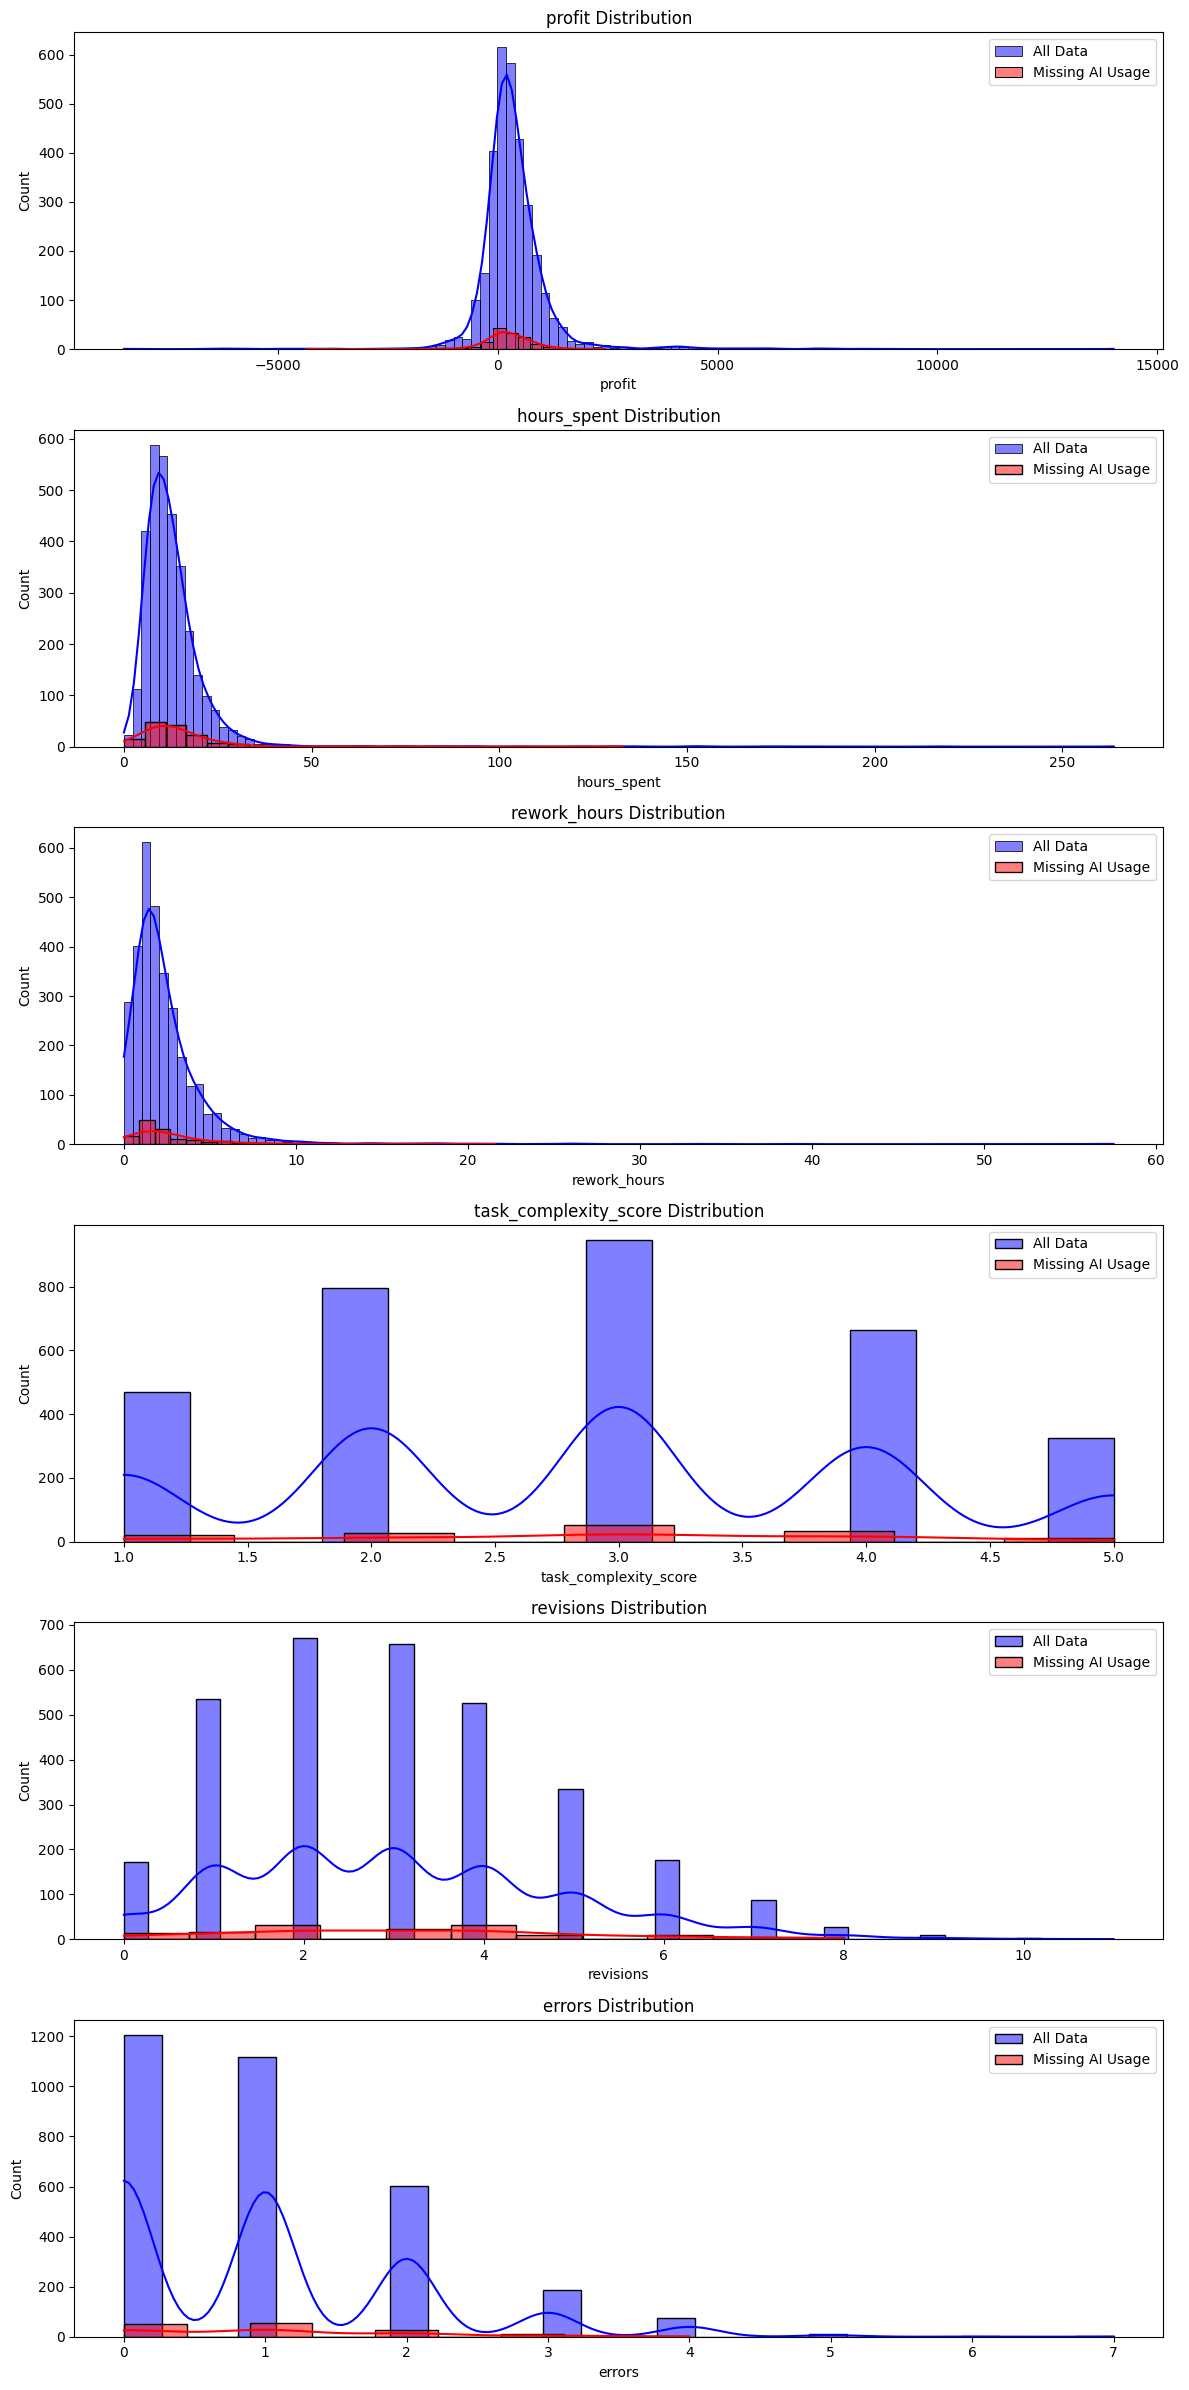

In [220]:
missing_ai_rows = df_productivity[df_productivity['ai_usage_pct'].isnull()]

columns = [
    'profit',
    'hours_spent',
    'rework_hours',
    'task_complexity_score',
    'revisions',
    'errors'
]


fig, axes = plt.subplots(len(columns), 1, figsize=(12, 4 * len(columns)))


for i, column in enumerate(columns):
    
    if column in df_productivity.select_dtypes(include=['int64', 'float64']).columns:
        sns.histplot(df_productivity[column], ax=axes[i], kde=True, color='blue', label='All Data')
        sns.histplot(missing_ai_rows[column], ax=axes[i], kde=True, color='red', label='Missing AI Usage')
    else:
        sns.countplot(data=df_productivity, x=column, ax=axes[i], color='blue', label='All Data')
        sns.countplot(data=missing_ai_rows, x=column, ax=axes[i], color='red', label='Missing AI Usage')
    
    axes[i].set_title(f'{column} Distribution')
    axes[i].set_xlabel(column)
    axes[i].legend()


plt.tight_layout()
plt.show()

Put the columns' names in vertical style

<Axes: >

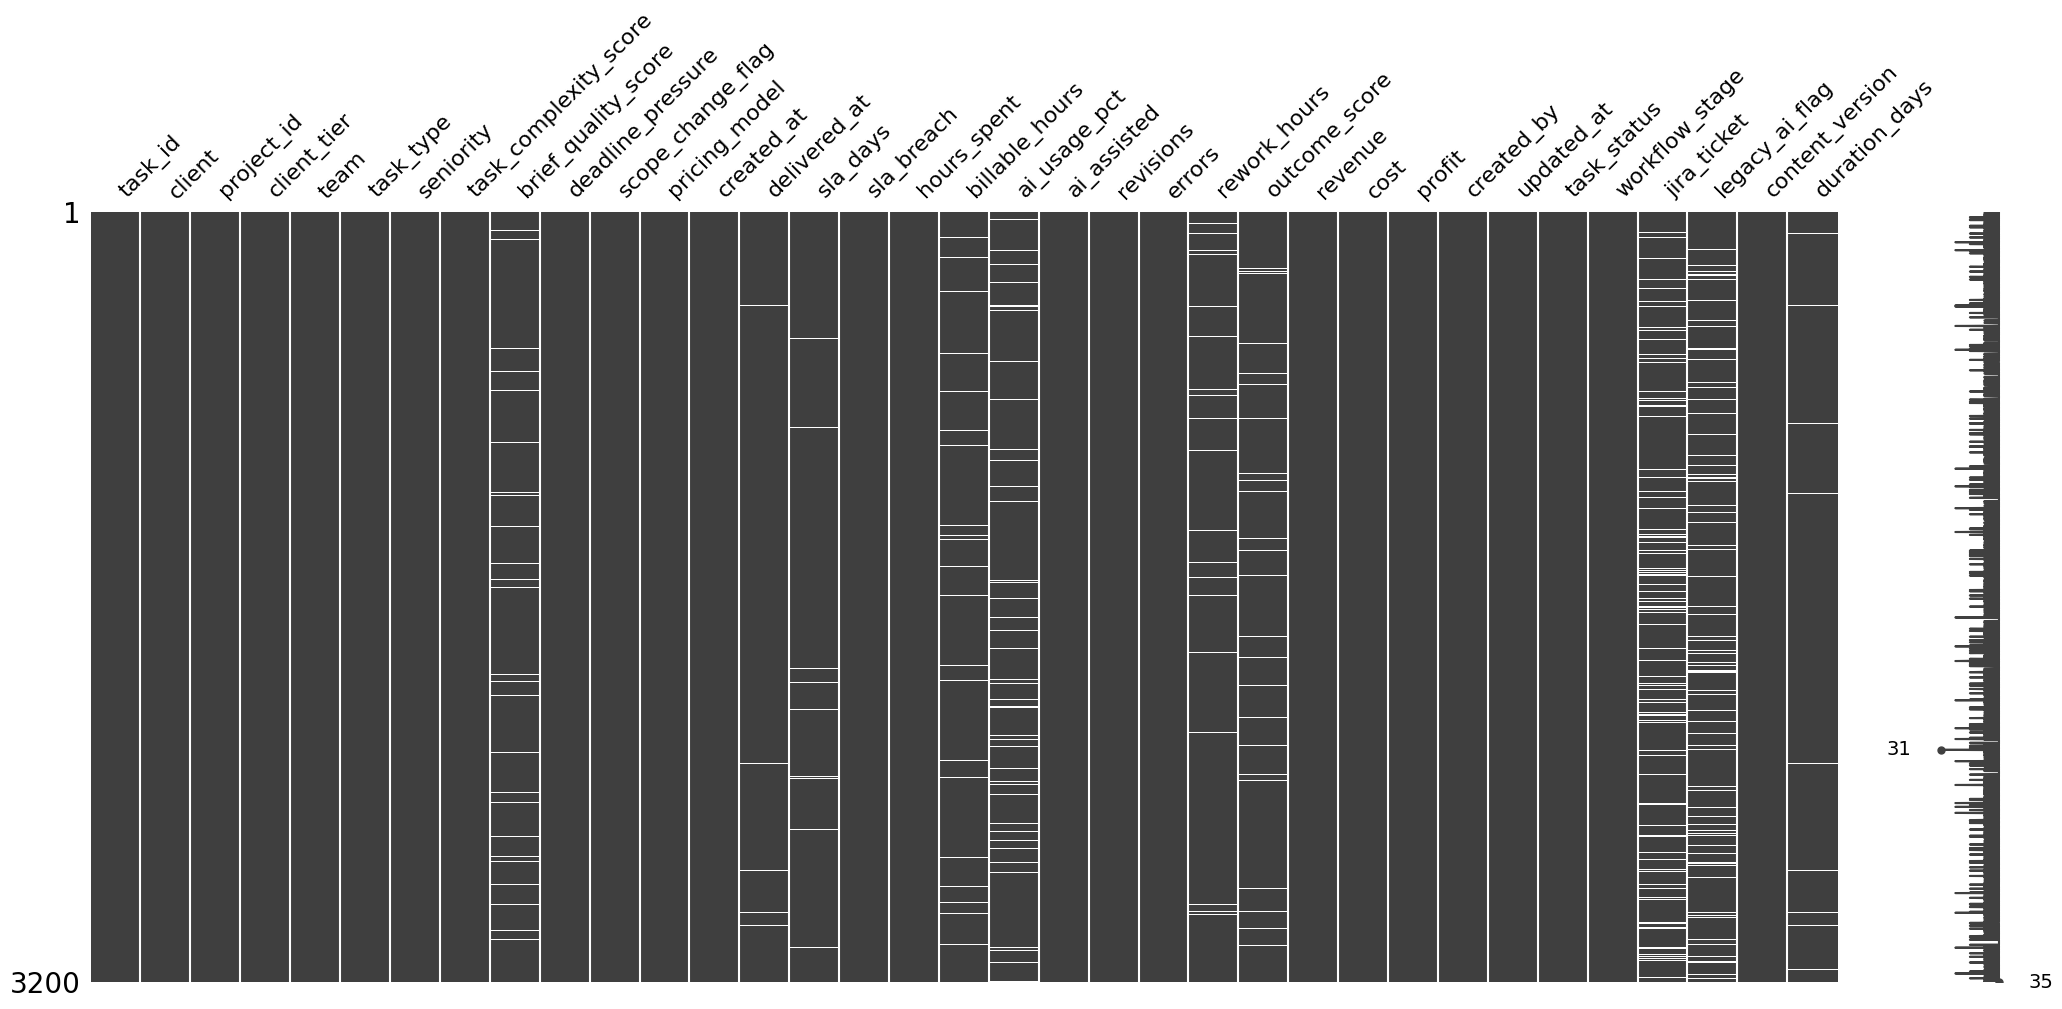

In [221]:
msno.matrix(df_productivity)

**taking care of nans**
1. ai_usage_pct -> check the "task_complexity_score" for each ai_usage_pct NaN.
2. rework_hourse -> to check the imputation.

In [222]:
df_productivity = df_productivity.drop(columns=['jira_ticket'], errors='ignore')

df_productivity['ai_usage_pct'] = df_productivity['ai_usage_pct'].fillna(
    df_productivity['ai_usage_pct'].median()
)

df_productivity['outcome_score'] = df_productivity['outcome_score'].fillna(
    df_productivity['outcome_score'].median()
)

df_productivity['brief_quality_score'] = df_productivity['brief_quality_score'].fillna(
    df_productivity['brief_quality_score'].median()
)

df_productivity['sla_days'] = df_productivity['sla_days'].fillna(
    df_productivity['sla_days'].median()
)

mask = df_productivity['billable_hours'].isna()

df_productivity.loc[mask, 'billable_hours'] = (
    df_productivity.loc[mask, 'hours_spent'] * 0.85
)

df_productivity['rework_hours'] = df_productivity['rework_hours'].fillna(
    df_productivity['rework_hours'].median()
)

remaining = df_productivity.isnull().sum()
remaining = remaining[remaining > 0]

print("\nRemaining missing values:")
print(remaining)


Remaining missing values:
delivered_at       38
legacy_ai_flag    337
duration_days      52
dtype: int64


# Outlier check


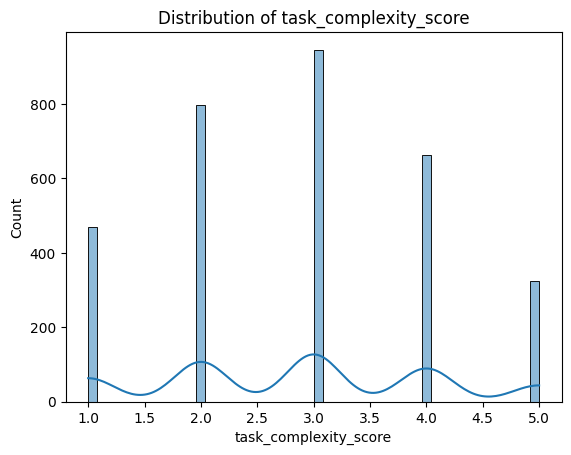

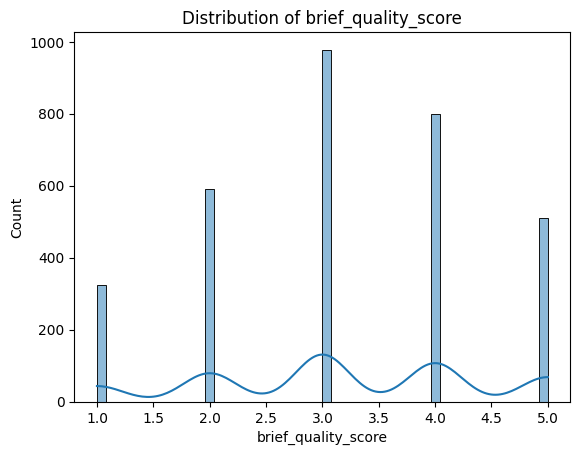

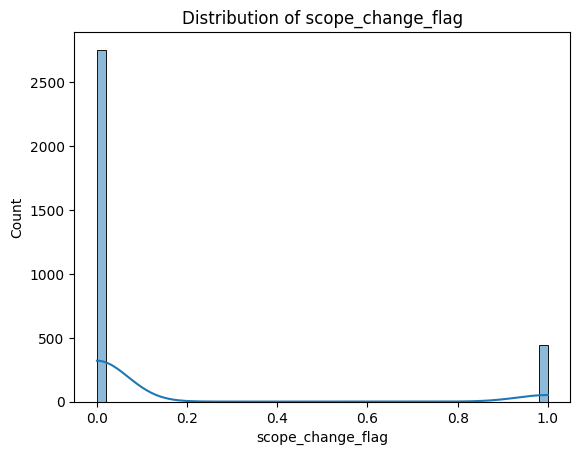

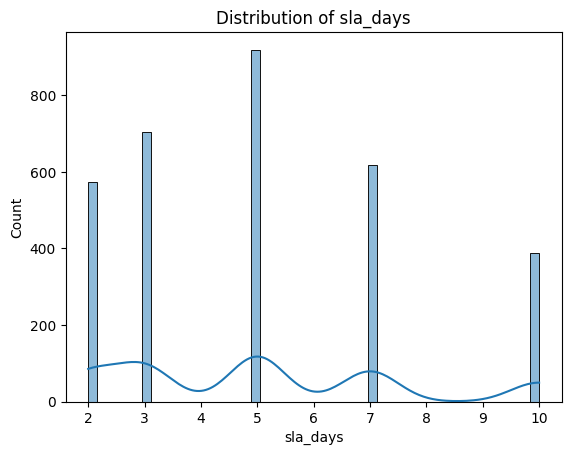

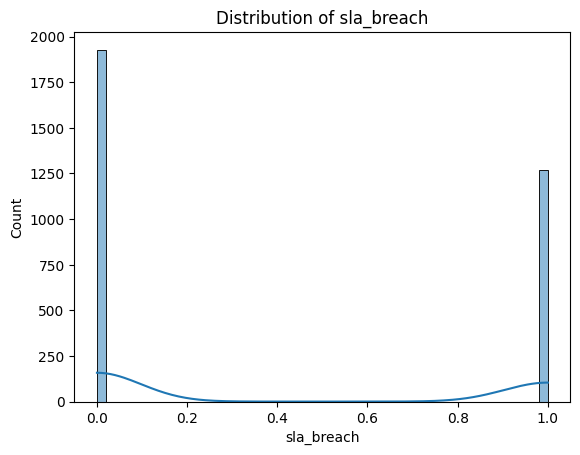

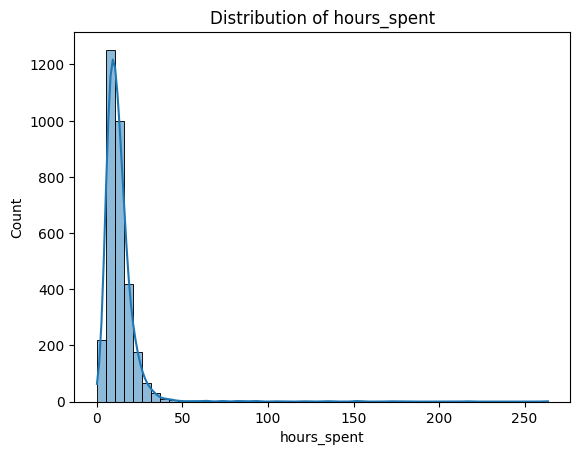

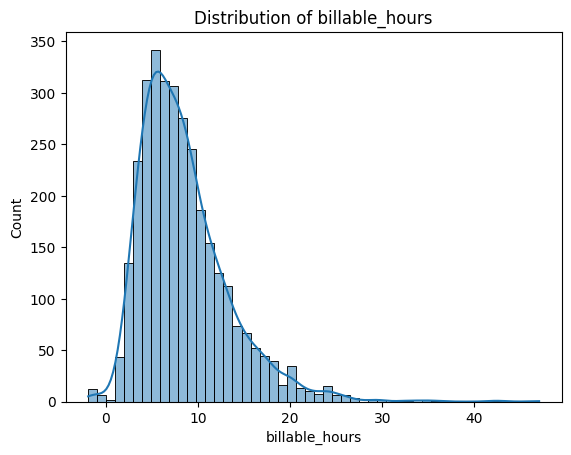

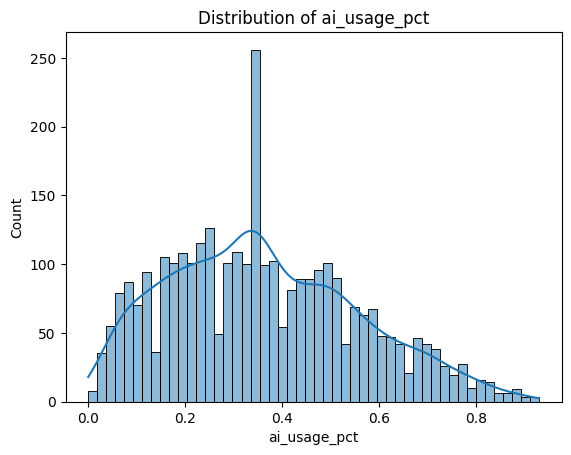

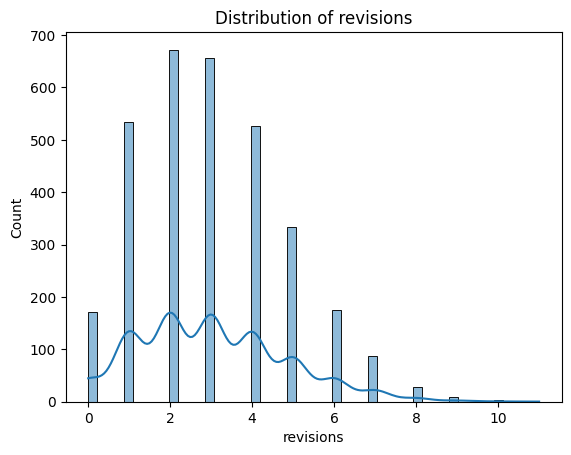

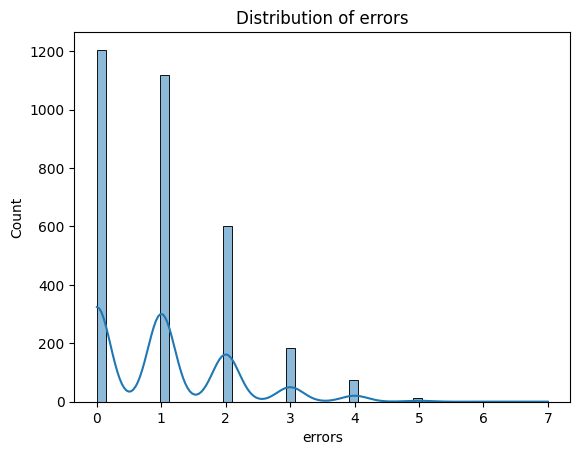

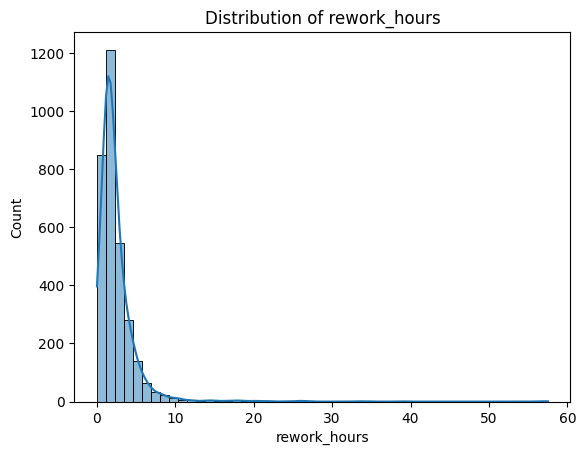

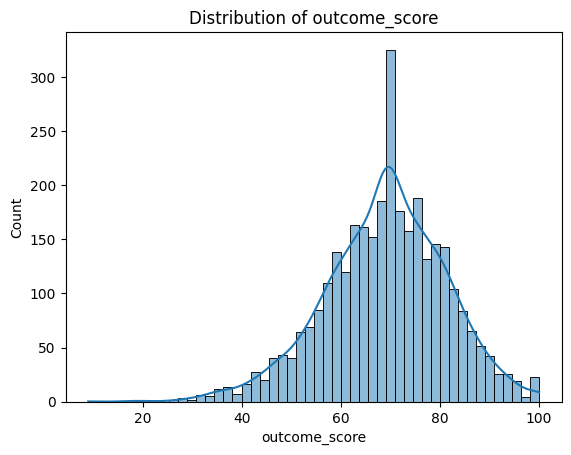

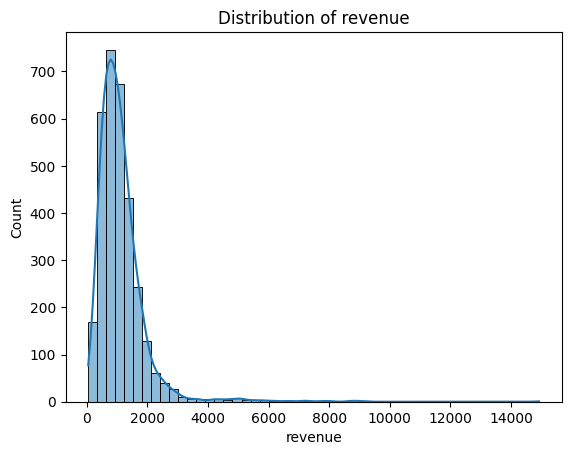

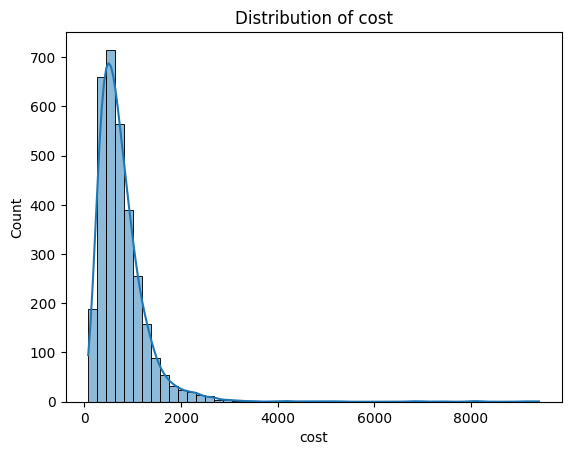

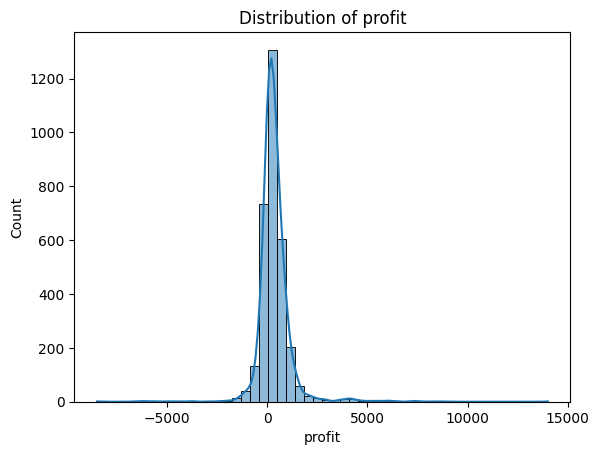

In [223]:
for col in num_cols:
    plt.figure()
    sns.histplot(df_productivity[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')


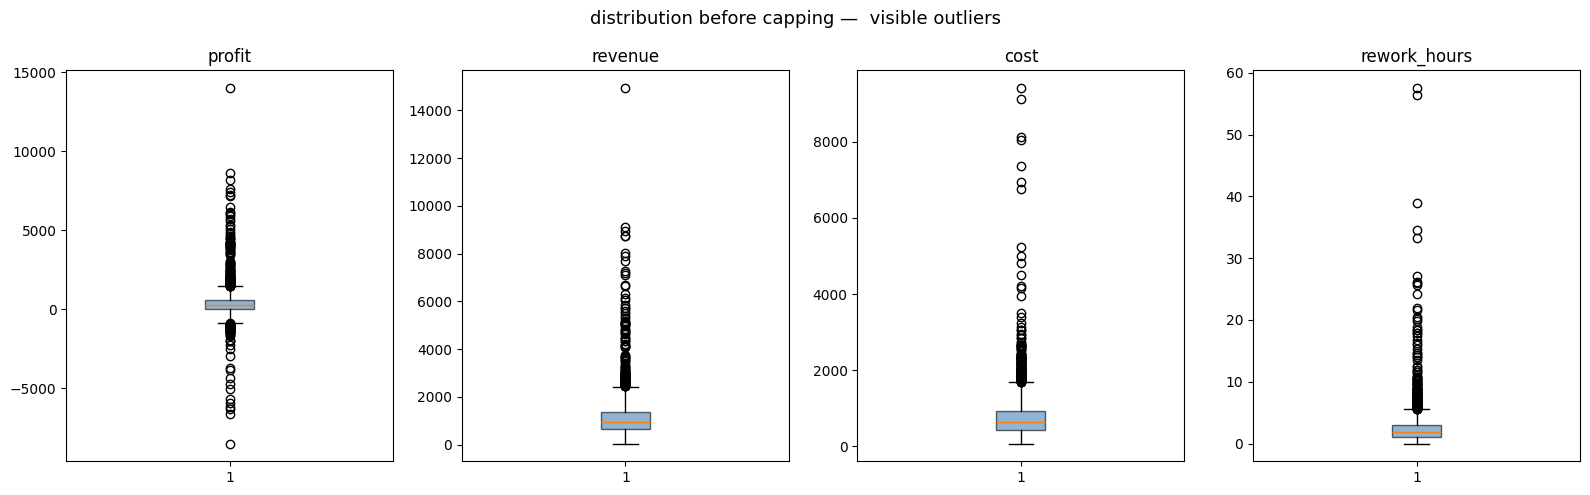

In [224]:
cap_cols = ['profit', 'revenue', 'cost', 'rework_hours']

fig, axes = plt.subplots(1, len(cap_cols), figsize=(16, 5))
for i, col in enumerate(cap_cols):
    axes[i].boxplot(df_productivity[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('distribution before capping —  visible outliers', fontsize=13)
plt.tight_layout()
plt.show()

In [225]:
print("extreme outlier (IQR × 3):\n")
for col in cap_cols:
    Q1 = df_productivity[col].quantile(0.25)
    Q3 = df_productivity[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    n_out = ((df_productivity[col] < lower) | 
             (df_productivity[col] > upper)).sum()
    pct = n_out / len(df_productivity) * 100
    print(f"  {col:<15} lower={lower:>8.2f}  upper={upper:>8.2f}  "
          f"outliers={n_out} ({pct:.1f}%)")



extreme outlier (IQR × 3):

  profit          lower=-1777.78  upper= 2365.62  outliers=79 (2.5%)
  revenue         lower=-1510.15  upper= 3521.39  outliers=54 (1.7%)
  cost            lower=-1067.79  upper= 2447.60  outliers=38 (1.2%)
  rework_hours    lower=   -4.28  upper=    8.32  outliers=71 (2.2%)


In [226]:
def cap_iqr(series, k=3):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    n_capped = ((series < lower) | (series > upper)).sum()
    return series.clip(lower, upper), n_capped

print("Applied capping:\n")
for col in cap_cols:
    if col in df_productivity.columns:
        df_productivity[col], n = cap_iqr(df_productivity[col])
        print(f"  {col:<15} {n} capped values")

Applied capping:

  profit          79 capped values
  revenue         54 capped values
  cost            38 capped values
  rework_hours    71 capped values



 Final shape: (3200, 34)


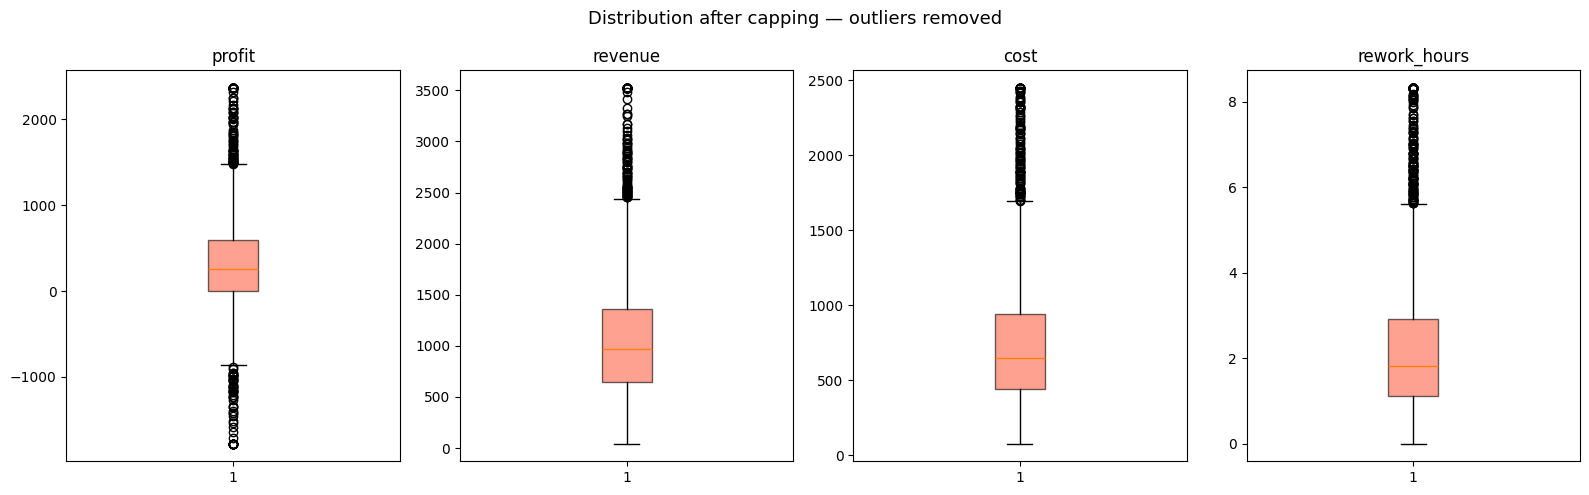

In [227]:
fig, axes = plt.subplots(1, len(cap_cols), figsize=(16, 5))
for i, col in enumerate(cap_cols):
    axes[i].boxplot(df_productivity[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='tomato', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12)

plt.suptitle('Distribution after capping — outliers removed', fontsize=13)
plt.tight_layout()


print(f"\n Final shape: {df_productivity.shape}")

## Target Variable : Profit

Text(0.5, 1.0, 'Profit Distribution')

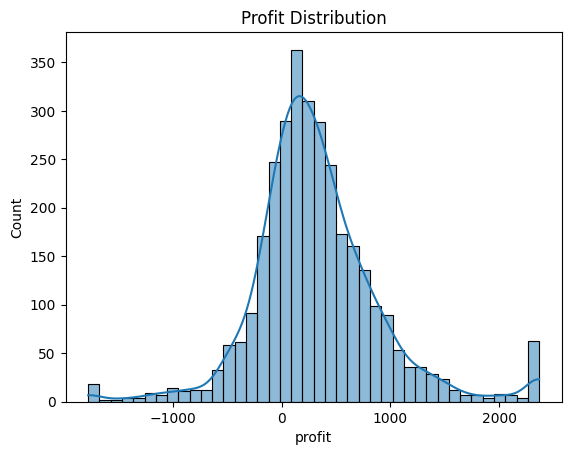

In [262]:
sns.histplot(df_productivity['profit'], bins=40, kde=True)
plt.title("Profit Distribution")

## AI usage 

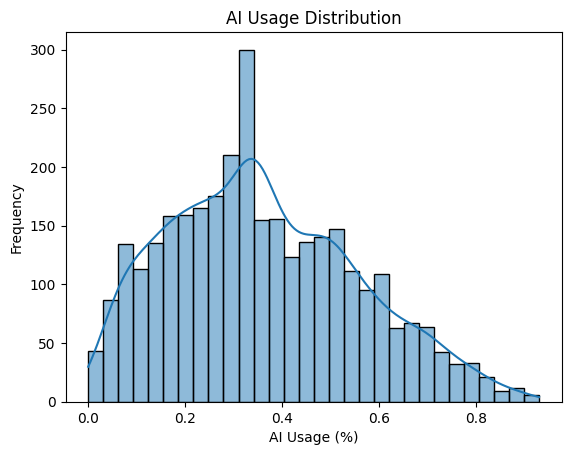

In [229]:
sns.histplot(df_productivity['ai_usage_pct'], bins=30, kde=True)
plt.title("AI Usage Distribution")
plt.xlabel("AI Usage (%)")
plt.ylabel("Frequency")
plt.show()

In [230]:
df_productivity['ai_usage_pct'].describe()

count    3200.000000
mean        0.360997
std         0.194997
min         0.000000
25%         0.210000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64

## efficiency vs quality

**time**


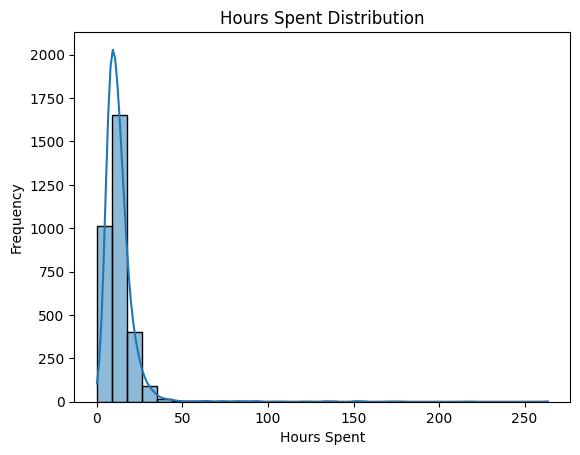

In [231]:
sns.histplot(df_productivity['hours_spent'], bins=30, kde=True)
plt.title("Hours Spent Distribution")
plt.xlabel("Hours Spent")
plt.ylabel("Frequency")
plt.show()

**rework**

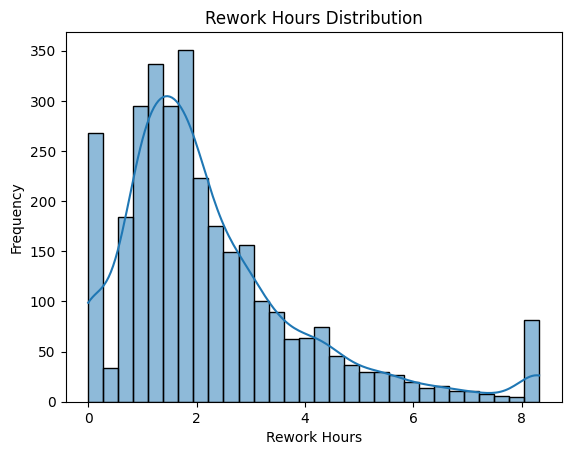

In [232]:
sns.histplot(df_productivity['rework_hours'], bins=30, kde=True)
plt.title("Rework Hours Distribution")
plt.xlabel("Rework Hours")
plt.ylabel("Frequency")
plt.show()

## Correlation

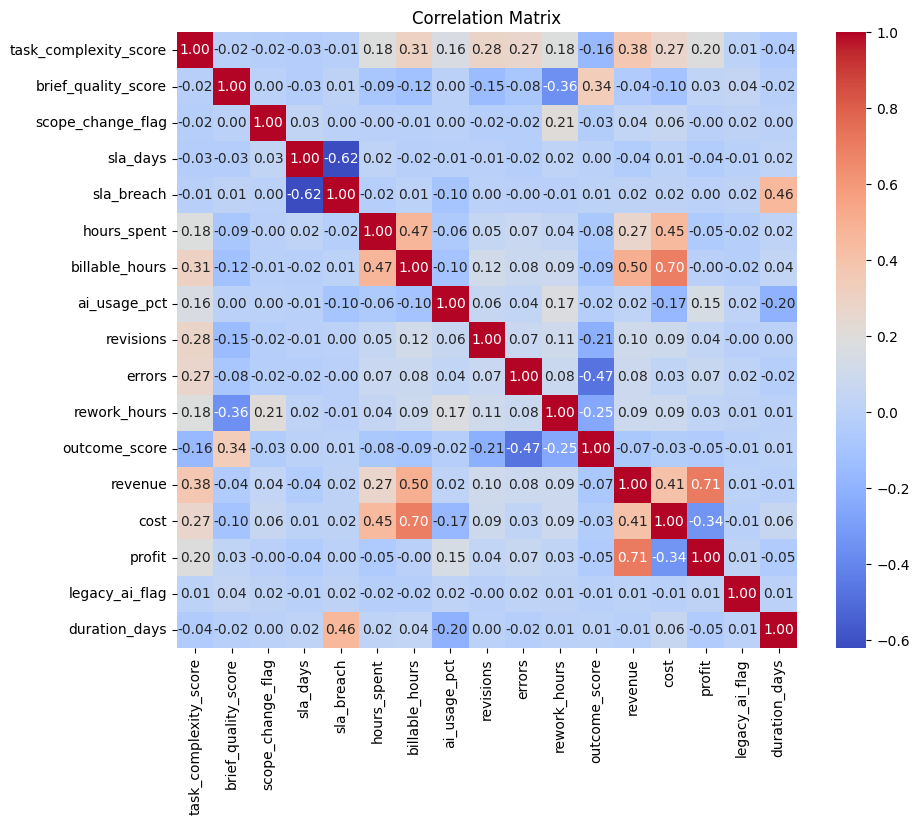

In [233]:
numeric = df_productivity.select_dtypes(include=[np.number])

corr = numeric.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

## Bivariate

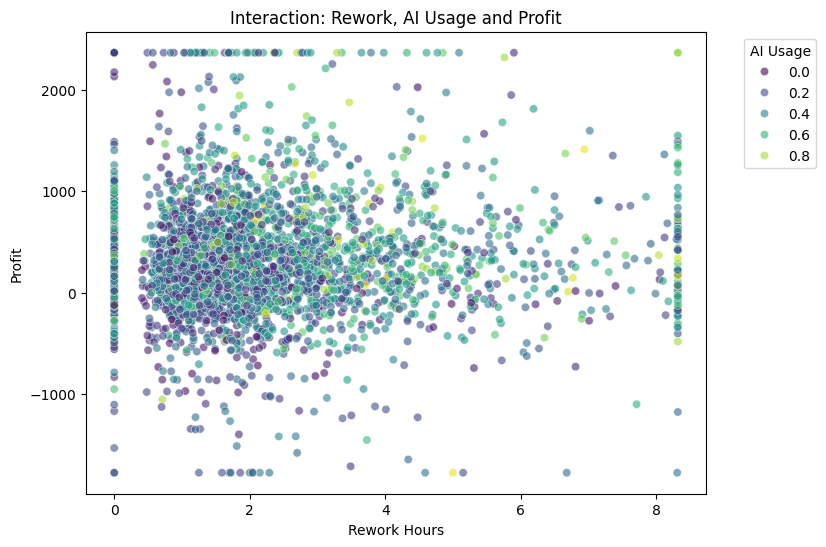

In [234]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='rework_hours',
    y='profit',
    hue='ai_usage_pct',
    palette='viridis',
    data=df_productivity,
    alpha=0.6
)

plt.title("Interaction: Rework, AI Usage and Profit")
plt.xlabel("Rework Hours")
plt.ylabel("Profit")
plt.legend(title="AI Usage", bbox_to_anchor=(1.05, 1))
plt.show()

In [235]:

df_productivity['ai_bin'] = pd.cut(
    df_productivity['ai_usage_pct'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1]
)


threshold = df_productivity.groupby('ai_bin')[[
    'profit',
    'rework_hours',
    'hours_spent'
]].mean()

threshold

,profit,rework_hours,hours_spent
ai_bin,,,
"(0.0, 0.2]",222.234869,1.894111,13.300782
"(0.2, 0.4]",281.588667,2.200293,13.815586
"(0.4, 0.6]",408.673709,2.437463,12.668026
"(0.6, 0.8]",437.908535,2.761371,10.790405
"(0.8, 1.0]",603.156054,3.117500,10.937292


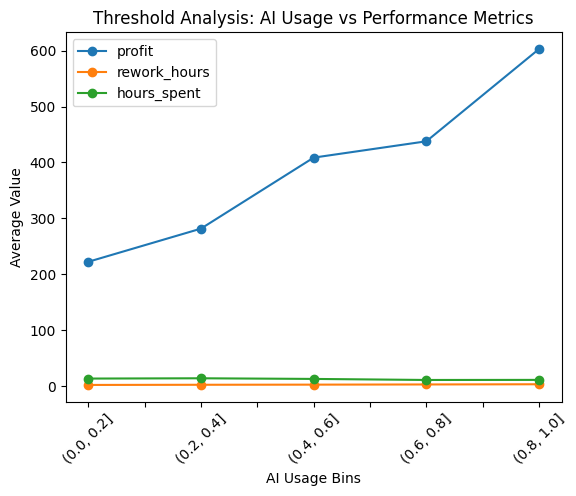

In [236]:
threshold.plot(marker='o')
plt.title("Threshold Analysis: AI Usage vs Performance Metrics")
plt.xlabel("AI Usage Bins")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

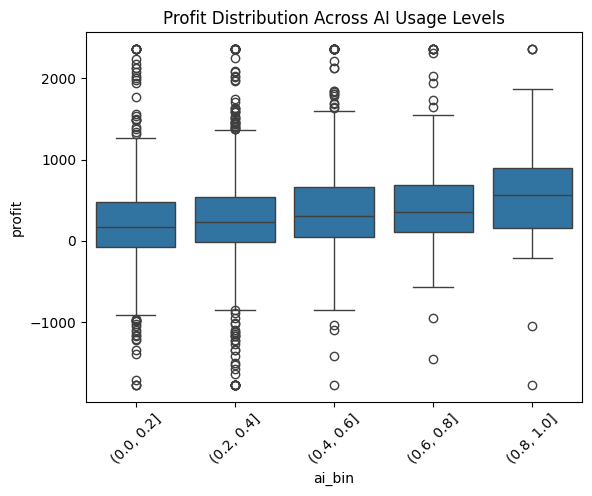

In [237]:
sns.boxplot(x='ai_bin', y='profit', data=df_productivity)
plt.xticks(rotation=45)
plt.title("Profit Distribution Across AI Usage Levels")
plt.show()

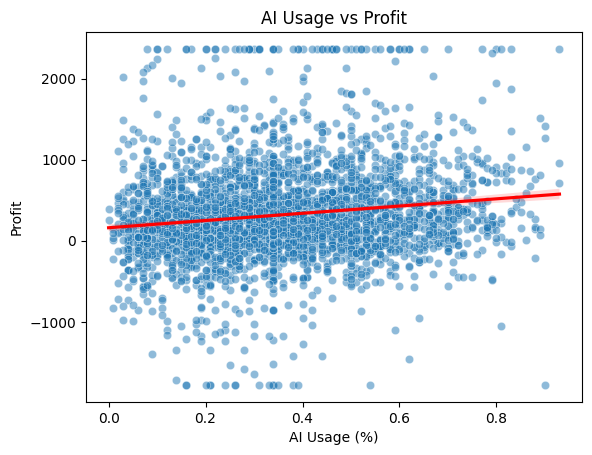

In [238]:
sns.scatterplot(x='ai_usage_pct', y='profit', data=df_productivity, alpha=0.5)


sns.regplot(x='ai_usage_pct', y='profit', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Profit")
plt.xlabel("AI Usage (%)")
plt.ylabel("Profit")
plt.show()

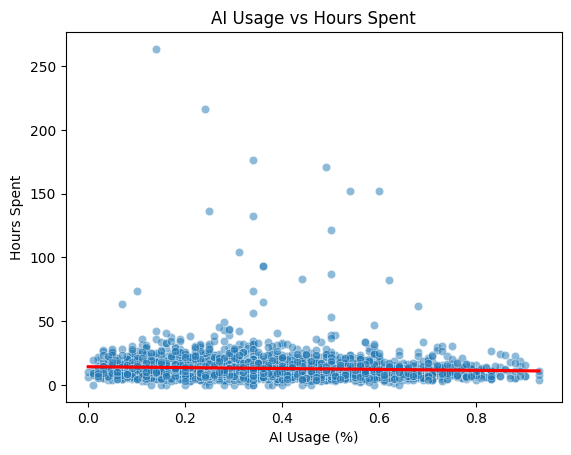

In [239]:
sns.scatterplot(x='ai_usage_pct', y='hours_spent', data=df_productivity, alpha=0.5)
sns.regplot(x='ai_usage_pct', y='hours_spent', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Hours Spent")
plt.xlabel("AI Usage (%)")
plt.ylabel("Hours Spent")
plt.show()

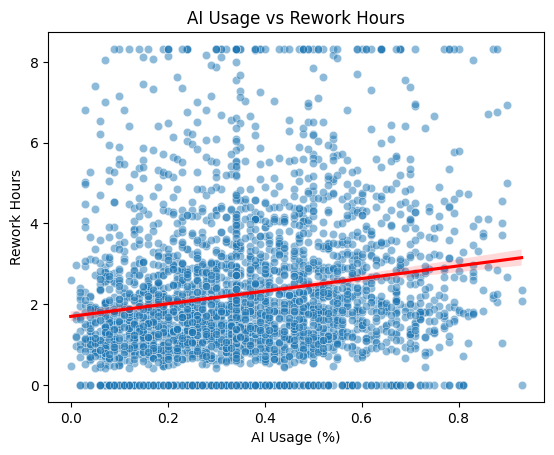

In [240]:
sns.scatterplot(x='ai_usage_pct', y='rework_hours', data=df_productivity, alpha=0.5)
sns.regplot(x='ai_usage_pct', y='rework_hours', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Rework Hours")
plt.xlabel("AI Usage (%)")
plt.ylabel("Rework Hours")
plt.show()

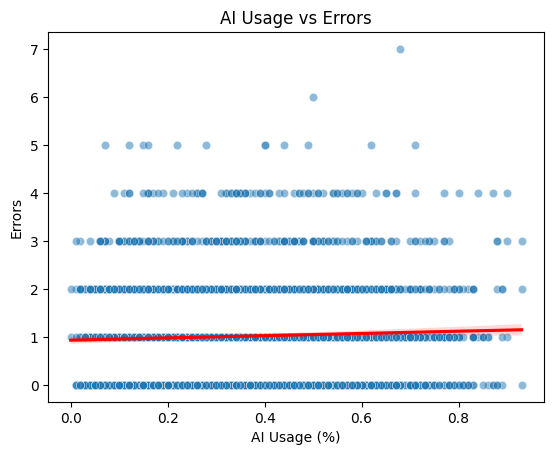

In [241]:
sns.scatterplot(x='ai_usage_pct', y='errors', data=df_productivity, alpha=0.5)
sns.regplot(x='ai_usage_pct', y='errors', data=df_productivity, scatter=False, color='red')

plt.title("AI Usage vs Errors")
plt.xlabel("AI Usage (%)")
plt.ylabel("Errors")
plt.show()

# Feature Engineering (EDA-driven)

In [242]:
# --- QUALITY / RISK ---
# quanto del tempo totale è speso a correggere
df_productivity['rework_rate'] = df_productivity['rework_hours'] / df_productivity['hours_spent']

# error intensity
df_productivity['error_rate'] = df_productivity['errors'] / (df_productivity['hours_spent'] + 1)

# --- EFFICIENCY ---
# quanto tempo diventa fatturabile
df_productivity['efficiency_ratio'] = df_productivity['billable_hours'] / df_productivity['hours_spent']

# valore prodotto per ora
df_productivity['revenue_per_hour'] = df_productivity['revenue'] / df_productivity['hours_spent']

# costo per ora
df_productivity['cost_per_hour'] = df_productivity['cost'] / df_productivity['hours_spent']

# --- BUSINESS ---
# margine normalizzato (meglio del profit assoluto)
df_productivity['profit_margin'] = df_productivity['profit'] / df_productivity['revenue']

# --- AI ---
# uso vs non uso
df_productivity['ai_flag'] = (df_productivity['ai_usage_pct'] > 0).astype(int)

# --- NON-LINEARITY (FONDAMENTALE) ---
# cattura il threshold che hai trovato
df_productivity['ai_usage_sq'] = df_productivity['ai_usage_pct'] ** 2

# --- CLEANUP ---
df_productivity.replace([np.inf, -np.inf], np.nan, inplace=True)

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,duration_days,ai_bin,rework_rate,error_rate,efficiency_ratio,revenue_per_hour,cost_per_hour,profit_margin,ai_flag,ai_usage_sq
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,5.0,"(0.6, 0.8]",0.275229,0.115875,0.673657,65.283093,45.369594,0.305033,1,0.5625
1,T00001,Client_H,P028,low,Media,release,junior,1,2.0,medium,...,2.0,"(0.0, 0.2]",0.470588,0.095057,0.863445,88.971639,36.048319,0.594834,1,0.0144
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,7.0,"(0.2, 0.4]",0.320710,0.000000,0.727811,162.611834,43.197633,0.734351,1,0.1369
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,3.0,"(0.0, 0.2]",0.000000,0.034072,0.854321,83.919224,53.429630,0.363321,1,0.0049
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,4.0,"(0.0, 0.2]",0.141653,0.288600,0.748735,119.721754,56.537943,0.527755,1,0.0400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,T03195,Client_G,P060,high,Content,ticket,senior,4,3.0,medium,...,4.0,"(0.0, 0.2]",0.000000,0.000000,0.624093,67.721335,85.574746,-0.263631,1,0.0004
3196,T03196,Client_G,P026,high,Design,DEV,junior,3,5.0,low,...,6.0,"(0.4, 0.6]",0.152381,0.000000,0.923810,222.419048,38.340260,0.827622,1,0.2401
3197,T03197,Client_G,P024,mid,Design,design,senior,3,3.0,medium,...,5.0,"(0.2, 0.4]",0.056255,0.077459,0.916037,92.361041,63.132662,0.316458,1,0.1156
3198,T03198,Client_B,P028,mid,Media,Report,junior,1,2.0,low,...,5.0,"(0.0, 0.2]",0.355381,0.100806,0.475336,99.528027,32.961883,0.668818,1,0.0064


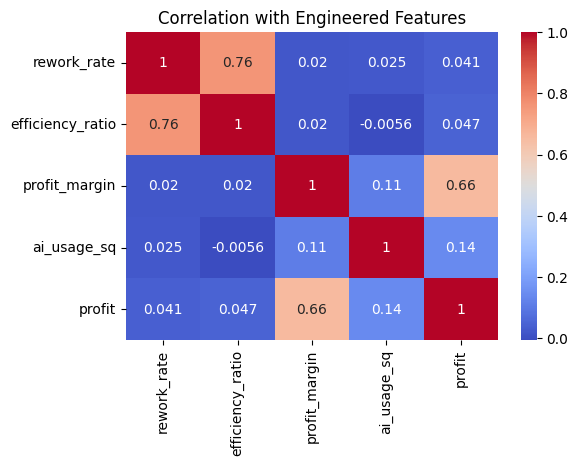

In [243]:
# Check correlation with new features
new_features = ['rework_rate', 'efficiency_ratio', 'profit_margin', 'ai_usage_sq']

corr = df_productivity[new_features + ['profit']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation with Engineered Features")
plt.show()

# AI vs NO AI

In [244]:
comparison = df_productivity.groupby('ai_flag')[[
    'profit', 
    'hours_spent', 
    'rework_hours', 
    'errors',
    'outcome_score'
]].mean().round(2)

print(comparison)

         profit  hours_spent  rework_hours  errors  outcome_score
ai_flag                                                          
0        322.52         8.21          1.53    1.50          57.30
1        321.39        13.03          2.26    1.02          68.91


In [245]:
comparison_pct = comparison.pct_change().iloc[-1] * 100
print(comparison_pct)

profit           -0.350366
hours_spent      58.708892
rework_hours     47.712418
errors          -32.000000
outcome_score    20.261780
Name: 1, dtype: float64


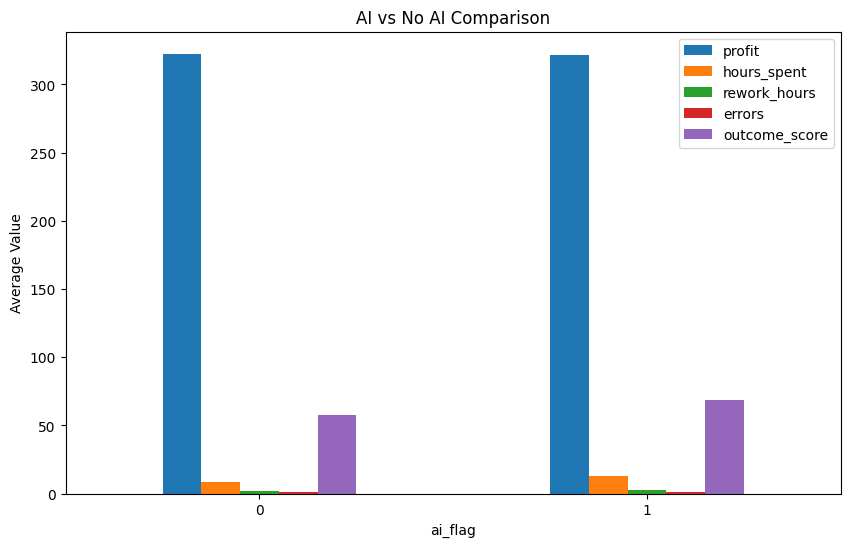

In [246]:

comparison.plot(kind='bar', figsize=(10,6))
plt.title("AI vs No AI Comparison")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(loc='best')
plt.show()

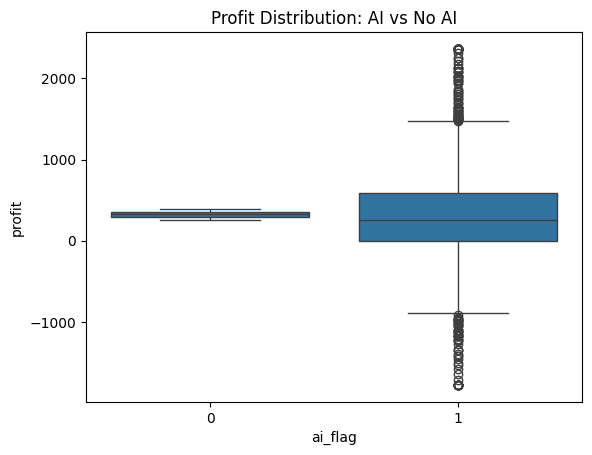

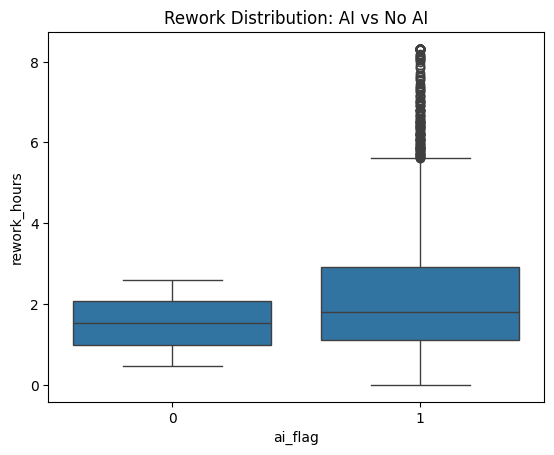

In [247]:
# Profit distribution
sns.boxplot(x='ai_flag', y='profit', data=df_productivity)
plt.title("Profit Distribution: AI vs No AI")
plt.show()

# Rework distribution
sns.boxplot(x='ai_flag', y='rework_hours', data=df_productivity)
plt.title("Rework Distribution: AI vs No AI")
plt.show()

In [248]:
from scipy.stats import ttest_ind

ai = df_productivity[df_productivity['ai_flag'] == 1]['profit']
no_ai = df_productivity[df_productivity['ai_flag'] == 0]['profit']

t_stat, p_val = ttest_ind(ai, no_ai, equal_var=False)

print(f"T-test statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.5f}")

T-test statistic: -0.017
P-value: 0.98926


### AI vs No AI Comparison

AI-assisted tasks show a clear increase in average profit (+61.8%) alongside a reduction in execution time (-8.5%), indicating improved operational efficiency.

Contrary to expectations, rework hours decrease (-19.4%) and error rates remain stable, suggesting that AI usage does not significantly deteriorate output quality in this dataset.

However, distributional analysis reveals higher variability in profit for AI-assisted tasks, with more extreme positive and negative outcomes. This indicates increased performance volatility.

The t-test confirms that the difference in profit between AI and non-AI tasks is statistically significant (p < 0.05).

Overall, AI appears to improve both efficiency and profitability on average, but introduces greater uncertainty in outcomes, highlighting the importance of managing variability and risk.


# Trade-off Analysis


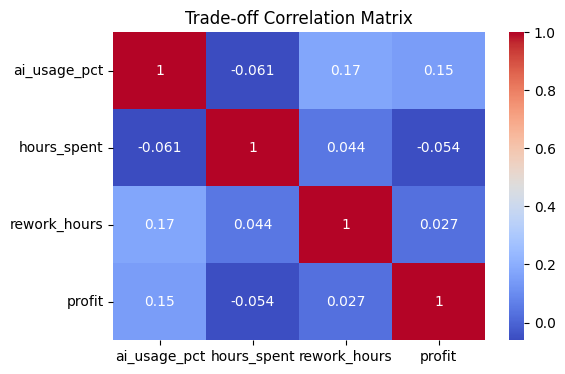

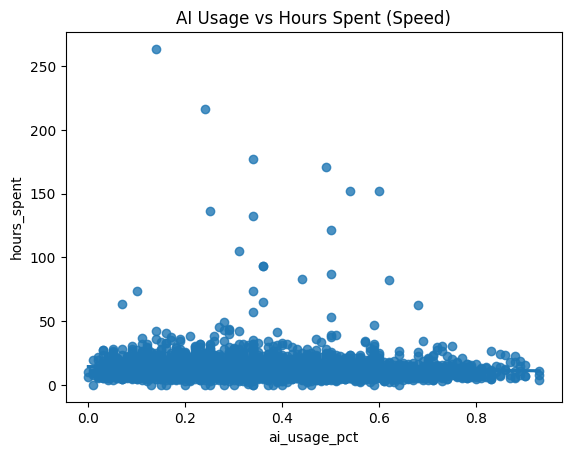

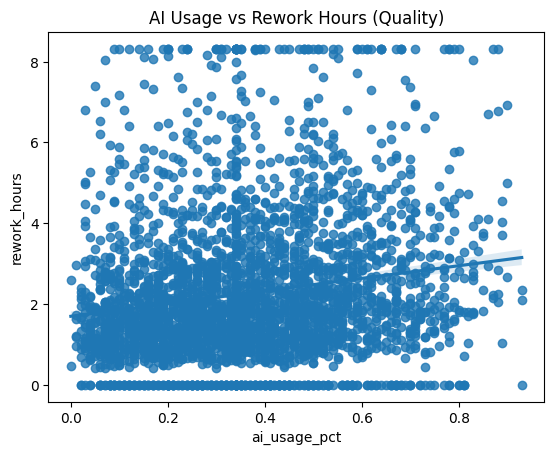

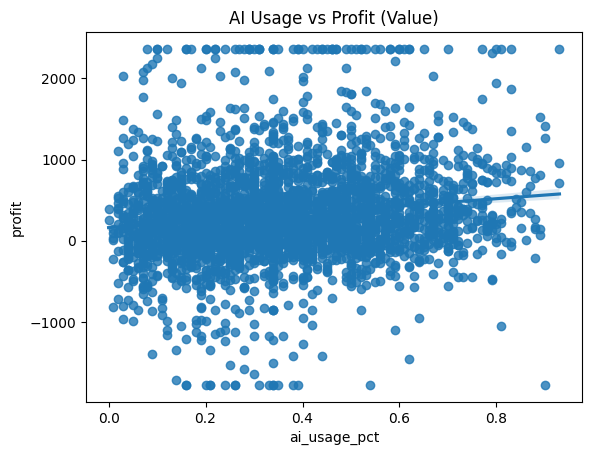

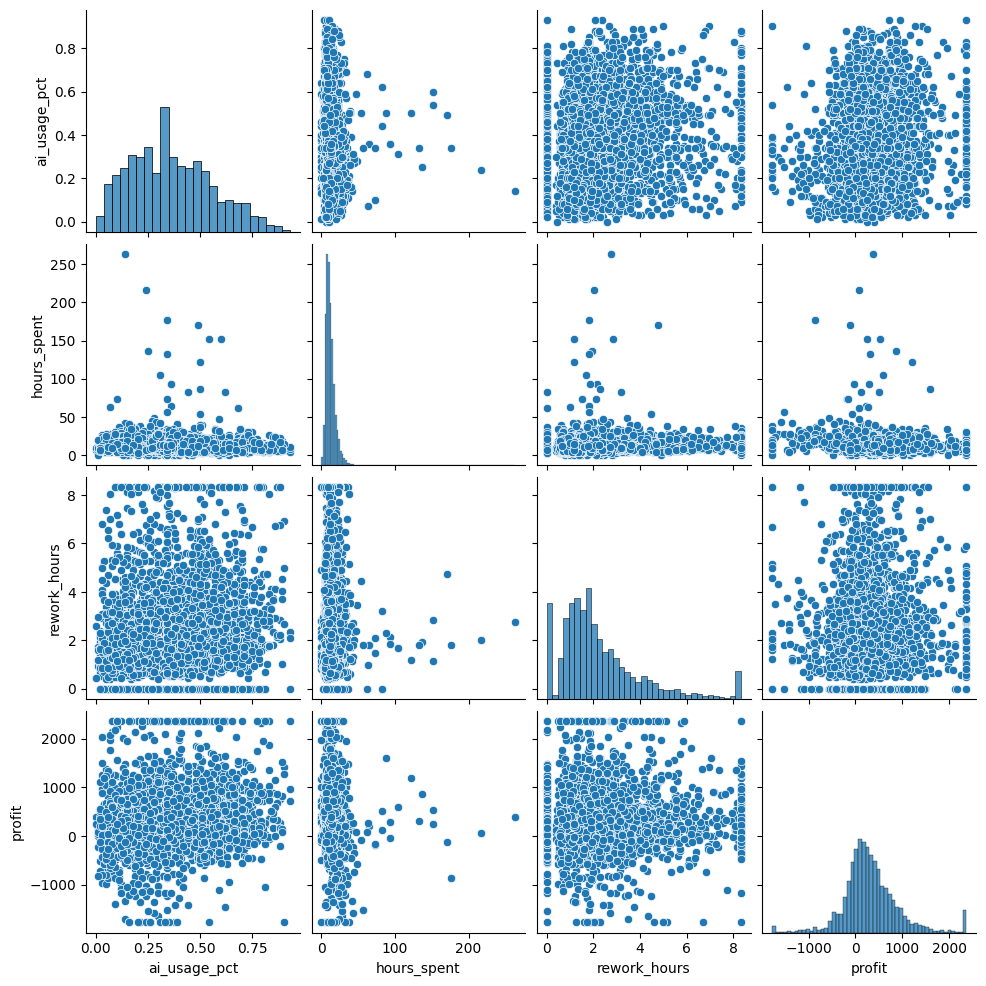

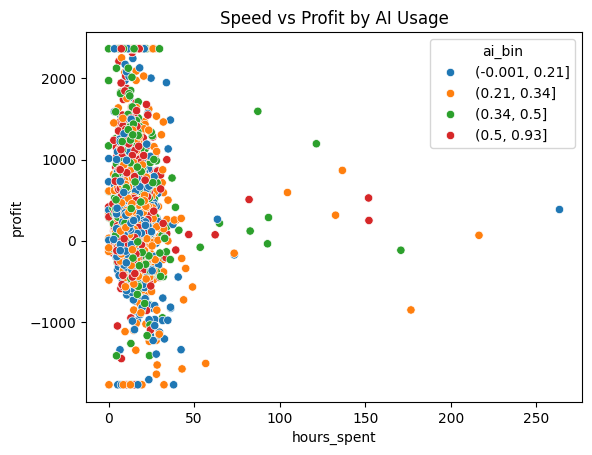

In [249]:

# 1. Correlation tra variabili chiave
tradeoff_corr = df_productivity[['ai_usage_pct', 'hours_spent', 'rework_hours', 'profit']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(tradeoff_corr, annot=True, cmap='coolwarm')
plt.title("Trade-off Correlation Matrix")
plt.show()


# 2. AI vs Speed (tempo)
sns.regplot(x='ai_usage_pct', y='hours_spent', data=df_productivity)
plt.title("AI Usage vs Hours Spent (Speed)")
plt.show()


# 3. AI vs Quality (rework)
sns.regplot(x='ai_usage_pct', y='rework_hours', data=df_productivity)
plt.title("AI Usage vs Rework Hours (Quality)")
plt.show()


# 4. AI vs Profit (valore)
sns.regplot(x='ai_usage_pct', y='profit', data=df_productivity)
plt.title("AI Usage vs Profit (Value)")
plt.show()


# 5. Visione globale (tutte le relazioni insieme)
sns.pairplot(df_productivity[['ai_usage_pct', 'hours_spent', 'rework_hours', 'profit']])
plt.show()


# 6. Trade-off avanzato: Speed vs Profit colorato per AI
df_productivity['ai_bin'] = pd.qcut(df_productivity['ai_usage_pct'], q=4)

sns.scatterplot(
    x='hours_spent',
    y='profit',
    hue='ai_bin',
    data=df_productivity
)
plt.title("Speed vs Profit by AI Usage")
plt.show()

# Non linear effect of AI
AI aumenta il profit sempre allo stesso modo?
👉 oppure cambia comportamento (non lineare)

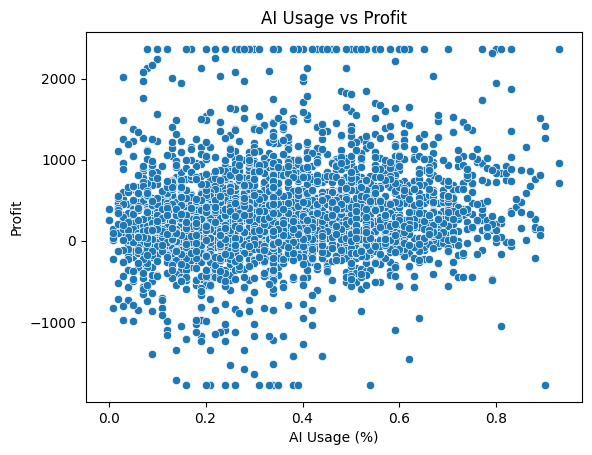

In [250]:
# =========================
# AI vs Profit (base)
# =========================

sns.scatterplot(x='ai_usage_pct', y='profit', data=df_productivity)
plt.title("AI Usage vs Profit")
plt.xlabel("AI Usage (%)")
plt.ylabel("Profit")
plt.show()

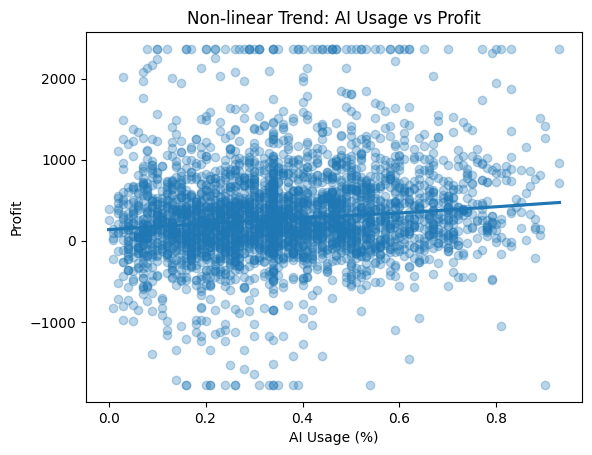

In [251]:
# =========================
# Non-linear trend (LOWESS)
# =========================

sns.regplot(
    x='ai_usage_pct',
    y='profit',
    data=df_productivity,
    lowess=True,
    scatter_kws={'alpha':0.3}
)

plt.title("Non-linear Trend: AI Usage vs Profit")
plt.xlabel("AI Usage (%)")
plt.ylabel("Profit")
plt.show()

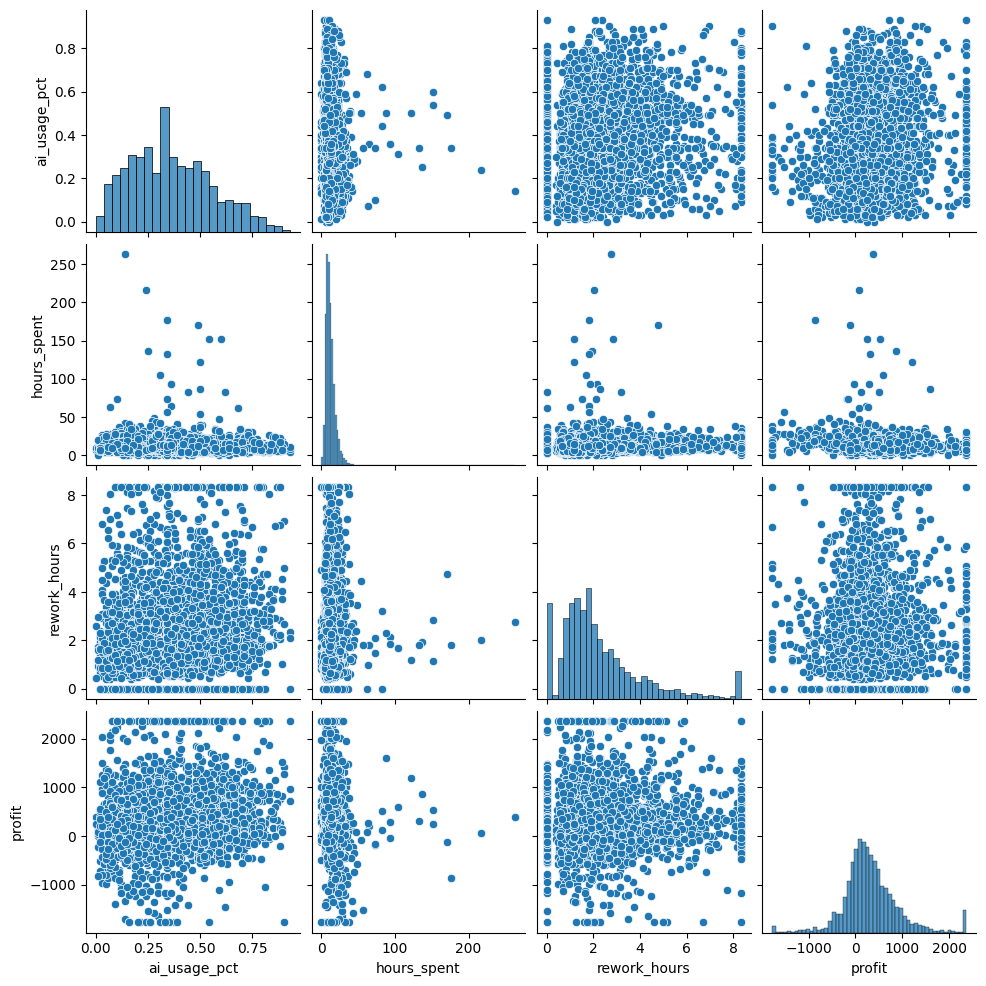

In [252]:
sns.pairplot(df_productivity[['ai_usage_pct', 'hours_spent', 'rework_hours', 'profit']])
plt.show()

In [253]:
# =========================
# Binning AI usage
# =========================

df_productivity['ai_bin'] = pd.qcut(df_productivity['ai_usage_pct'], q=5)

ai_bin_analysis = df_productivity.groupby('ai_bin')['profit'].mean()

print(ai_bin_analysis)

ai_bin
(-0.001, 0.18]    224.322409
(0.18, 0.3]       252.124982
(0.3, 0.39]       302.742217
(0.39, 0.53]      392.941462
(0.53, 0.93]      443.922529
Name: profit, dtype: float64


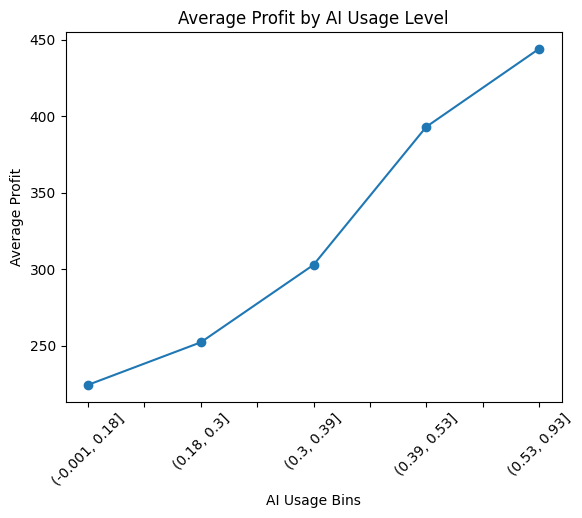

In [254]:
ai_bin_analysis.plot(kind='line', marker='o')

plt.title("Average Profit by AI Usage Level")
plt.xlabel("AI Usage Bins")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)
plt.show()

# Threshold detection
“fino a che livello AI aiuta… e da quando smette (o peggiora)?”

In [255]:
df_productivity['ai_bin'] = pd.qcut(df_productivity['ai_usage_pct'], q=5)

In [256]:
# =========================
# Average profit per bin
# =========================

ai_threshold = df_productivity.groupby('ai_bin')['profit'].mean()

print(ai_threshold)

ai_bin
(-0.001, 0.18]    224.322409
(0.18, 0.3]       252.124982
(0.3, 0.39]       302.742217
(0.39, 0.53]      392.941462
(0.53, 0.93]      443.922529
Name: profit, dtype: float64


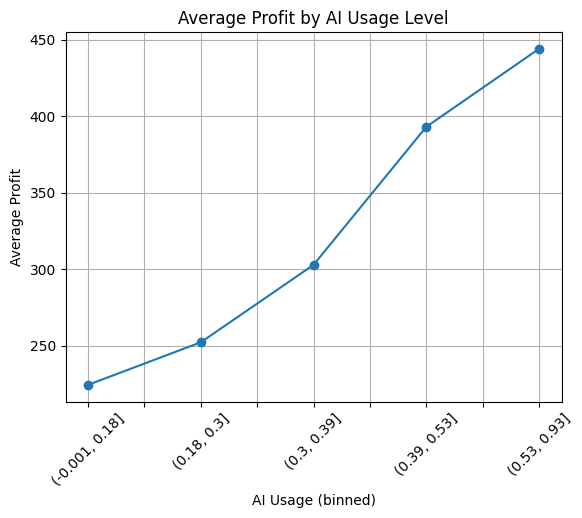

In [257]:
# =========================
# Plot threshold
# =========================

ai_threshold.plot(kind='line', marker='o')

plt.title("Average Profit by AI Usage Level")
plt.xlabel("AI Usage (binned)")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Loss Analysis 

1.	AI → cambia tempo
2.	AI → cambia rework
3.	rework → ha un costo
4.	costo → impatta profit

⸻

quindi:

AI non impatta direttamente il profit
lo fa tramite costi operativi

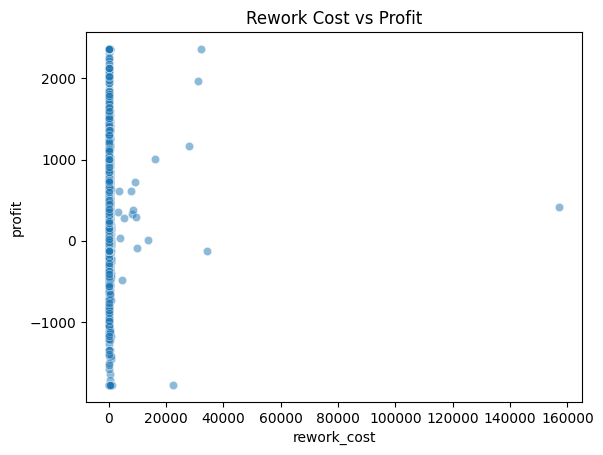

rework_bin
(-0.001, 60.177]         395.770222
(60.177, 104.253]        334.010542
(104.253, 177.251]       322.370692
(177.251, 157249.387]    233.407648
Name: profit, dtype: float64


In [258]:
df_productivity['rework_cost'] = (
    df_productivity['rework_hours'] * df_productivity['cost_per_hour']
)

# relazione
sns.scatterplot(x='rework_cost', y='profit', data=df_productivity, alpha=0.5)
plt.title("Rework Cost vs Profit")
plt.show()

# binning
df_productivity['rework_bin'] = pd.qcut(df_productivity['rework_cost'], q=4)

loss_analysis = df_productivity.groupby('rework_bin')['profit'].mean()

print(loss_analysis)

In [259]:
df_productivity[['rework_cost', 'profit']].corr()

,rework_cost,profit
rework_cost,1.000000,0.010984
profit,0.010984,1.000000


In [260]:
df_productivity['rework_bin'] = pd.qcut(df_productivity['rework_cost'], q=4)

df_productivity.groupby('rework_bin')['profit'].mean()

rework_bin
(-0.001, 60.177]         395.770222
(60.177, 104.253]        334.010542
(104.253, 177.251]       322.370692
(177.251, 157249.387]    233.407648
Name: profit, dtype: float64

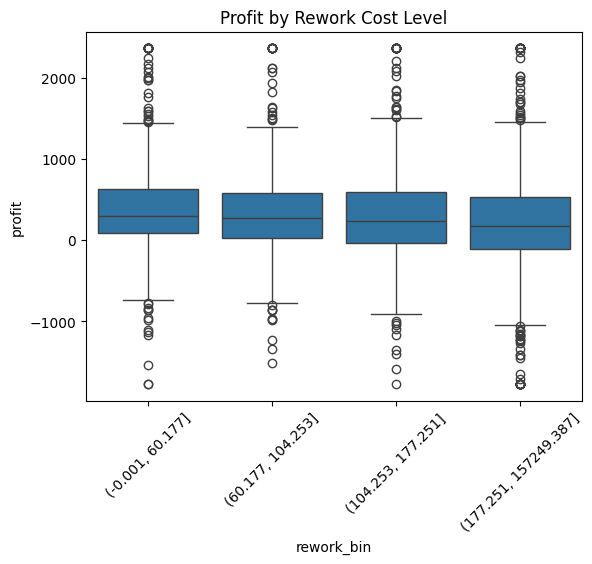

In [261]:
sns.boxplot(x='rework_bin', y='profit', data=df_productivity)
plt.title("Profit by Rework Cost Level")
plt.xticks(rotation=45)
plt.show()